# Chromatin copy number correction - With Shuffled Replication times

July 24, 2024

## Goal:
Show that by shuffling the replication times, we do not get the same copy number correction effect. That is, the correction is working properly because the PTR's do not change much from the 1:1 line. When the replication times are shuffled, the PTR values change in an uncorrelated manner.

In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
from src.ChromatinCopyNumberCorrector import ChromatinCopyNumberCorrector

corrector1 = ChromatinCopyNumberCorrector()

In [5]:
corrector1.load_chromatin_data(1)

0/5578 - 00:00:01.565
200/5578 - 00:01:26.458
400/5578 - 00:02:54.027
600/5578 - 00:04:12.727
800/5578 - 00:06:11.513
1000/5578 - 00:08:05.749
1200/5578 - 00:09:58.771
1400/5578 - 00:11:47.054
1600/5578 - 00:13:07.814
1800/5578 - 00:14:38.046
2000/5578 - 00:16:16.833
2200/5578 - 00:17:55.928
2400/5578 - 00:19:20.627
2600/5578 - 00:20:40.150
2800/5578 - 00:22:05.888
3000/5578 - 00:23:31.406
3200/5578 - 00:25:00.809
3400/5578 - 00:26:42.160
3600/5578 - 00:28:29.792
3800/5578 - 00:30:17.906
4000/5578 - 00:31:57.656
4200/5578 - 00:33:30.530
4400/5578 - 00:35:03.798
4600/5578 - 00:36:29.583
4800/5578 - 00:38:15.838
5000/5578 - 00:39:55.496
5200/5578 - 00:41:39.683
5400/5578 - 00:43:13.794


In [33]:
from src.figure_configs import save_figure_for_paper
    
def save_corrections_all_configs(corrector1, save_dir):

    for config_type in ['shared']:

        # Load config type and save copy correciton and PTRs to disk
        corrector1.load_config_type(config_type)
        
        # Shuffle the replication timing to see if the 
        # copy number effects are true.
        corrector1.correct_for_copy_number(shuffle=True)
        corrector1.compute_ptrs()
        corrector1.save_files(save_dir)

        # Save PTR comparison
        fig = corrector1.plot_ptrs()
        save_path = f"{save_dir}/ptrs_rep{corrector1.replicate}_{corrector1.config_type}.png"
        save_figure_for_paper(save_path)
        plt.close()


In [34]:
save_dir = 'output/copy_correction_shuffled/chromatin/'

save_corrections_all_configs(corrector1, save_dir)

Saved to output/copy_correction_shuffled/chromatin//ptrs_rep1_shared.csv
Saved to output/copy_correction_shuffled/chromatin//norm_corr_scaling_rep1_shared.csv
Saved to output/copy_correction_shuffled/chromatin//raw_sums_rep1_shared.csv
Saved to output/copy_correction_shuffled/chromatin//normalized_corrected_rep1_shared.csv


Text(0.5, 1.0, 'Shuffled Replication profile, PTR comparison')

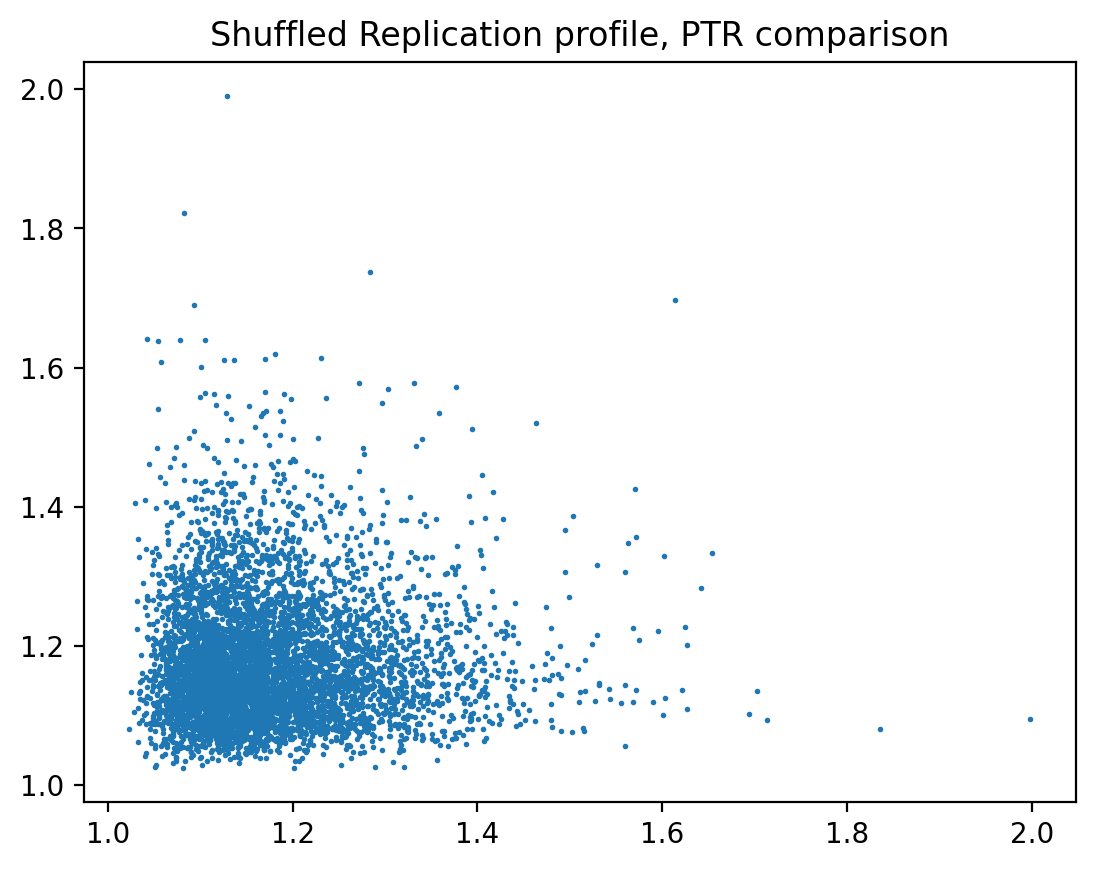

In [37]:
shuffled_ptrs = pd.read_csv('output/copy_correction_shuffled/chromatin/ptrs_rep1_shared.csv')\
    .set_index('orf_name')

plt.scatter(shuffled_ptrs.normalized_raw_ptr,
            shuffled_ptrs.normalized_corrected_ptr, s=1)
plt.title("Shuffled Replication profile, PTR comparison")

In [38]:
corrector2 = ChromatinCopyNumberCorrector()
corrector2.load_chromatin_data(2)

0/5578 - 00:00:01.630
200/5578 - 00:01:24.821
400/5578 - 00:02:54.418
600/5578 - 00:04:11.466
800/5578 - 00:06:12.219
1000/5578 - 00:08:06.713
1200/5578 - 00:10:00.814
1400/5578 - 00:25:23.465
1600/5578 - 00:41:43.343
1800/5578 - 00:43:13.631
2000/5578 - 00:44:51.426
2200/5578 - 00:46:29.351
2400/5578 - 00:47:51.979
2600/5578 - 00:49:08.171
2800/5578 - 00:52:21.459
3000/5578 - 00:53:44.119
3200/5578 - 01:10:34.273
3400/5578 - 01:12:13.604
3600/5578 - 01:13:58.796
3800/5578 - 01:23:11.684
4000/5578 - 01:25:21.632
4200/5578 - 01:27:40.408
4400/5578 - 01:29:11.005
4600/5578 - 01:36:58.039
4800/5578 - 01:54:23.516
5000/5578 - 01:56:02.061
5200/5578 - 01:59:06.418
5400/5578 - 02:00:39.508


In [39]:
save_corrections_all_configs(corrector2, save_dir)

Saved to output/copy_correction_shuffled/chromatin//ptrs_rep2_shared.csv
Saved to output/copy_correction_shuffled/chromatin//norm_corr_scaling_rep2_shared.csv
Saved to output/copy_correction_shuffled/chromatin//raw_sums_rep2_shared.csv
Saved to output/copy_correction_shuffled/chromatin//normalized_corrected_rep2_shared.csv
